In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('student_performance.csv')
print("Dataset is inserted successfully!")

Dataset is inserted successfully!


In [8]:
conn = sqlite3.connect('students.db')
cursor = conn.cursor()

df.to_sql("students", conn, if_exists="replace", index=False)

result = pd.read_sql("SELECT * FROM students LIMIT 5", conn)

result

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [9]:
def run_query(sql,description="students"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

In [10]:
query1 = """
  SELECT student_id,name,department,math_score,attendance_percentage
  FROM students
  LIMIT 10
"""
result1 = run_query(query1,"Query 1:First 10 Students (SELECT + LIMIT)")

Query 1:First 10 Students (SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


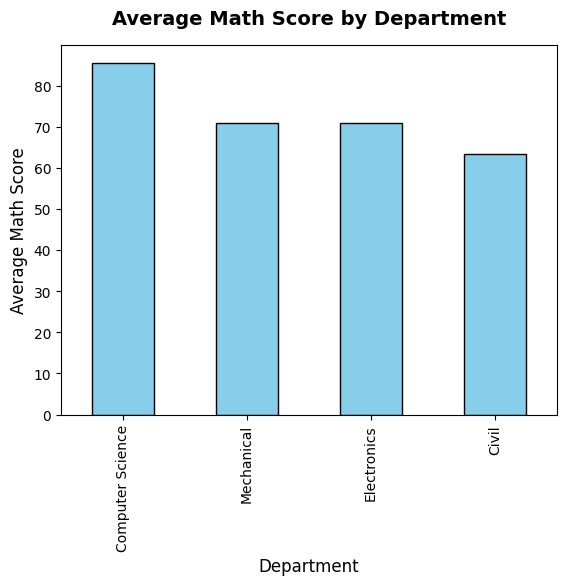

In [11]:
query = """
SELECT department, AVG(math_score) AS avg_math_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC;
"""
df_plot = pd.read_sql_query(query, conn)

ax = df_plot.plot(kind='bar', x='department', y='avg_math_score', color='skyblue', edgecolor='black', legend=False)

ax.set_title('Average Math Score by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Average Math Score', fontsize=12)

plt.show()

In [12]:
print("Before fixing nulls:")
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}\n")

df['name'] = df['name'].fillna('Unknown Student')
df['department'] = df['department'].fillna('Unassigned')

if df['math_score'].isnull().any():
    median_math = df['math_score'].median()
    df['math_score'] = df['math_score'].fillna(median_math)
    print(f"Filled missing math scores with median: {median_math}")

if 'attendance_percentage' in df.columns and df['attendance_percentage'].isnull().any():
    median_attendance = df['attendance_percentage'].median()
    df['attendance_percentage'] = df['attendance_percentage'].fillna(median_attendance)
    print(f"Filled missing attendance with median: {median_attendance}")

print("\nAfter fixing nulls and reloading to SQLite:")
print(f"Total missing values remaining: {df.isnull().sum().sum()}")

Before fixing nulls:
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64
Total missing values: 0


After fixing nulls and reloading to SQLite:
Total missing values remaining: 0


In [14]:
df_cleaned = df.drop(columns=['city'], errors='ignore')

df_cleaned = df_cleaned.dropna(subset=['student_id', 'name'])

df_cleaned['department'] = df_cleaned['department'].fillna('Unassigned')

if 'math_score' in df_cleaned.columns:
    median_math = df_cleaned['math_score'].median()
    df_cleaned['math_score'] = df_cleaned['math_score'].fillna(median_math)

if 'attendance_percentage' in df_cleaned.columns:
    median_attendance = df_cleaned['attendance_percentage'].median()
    df_cleaned['attendance_percentage'] = df_cleaned['attendance_percentage'].fillna(median_attendance)

print("Cleaned shape:", df_cleaned.shape)
print("Remaining nulls:", df_cleaned.isnull().sum().sum())

Cleaned shape: (30, 12)
Remaining nulls: 0


In [15]:
df_cleaned.to_sql("students", conn, if_exists="replace", index=False)
print("Cleaned dataset successfully reloaded to SQLite!")

result = pd.read_sql("SELECT * FROM students LIMIT 5", conn)
print("\nFirst 5 rows of cleaned database:")
print(result)

Cleaned dataset successfully reloaded to SQLite!

First 5 rows of cleaned database:
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage  admission_year  
0                     92            2023  


In [16]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, mean

spark = SparkSession.builder \
    .appName("StudentDataCleaning") \
    .getOrCreate()

df = spark.read.csv('student_performance.csv', header=True, inferSchema=True)

df_cleaned = df.drop("city")
df_cleaned = df_cleaned.dropna(subset=["student_id", "name"])
df_cleaned = df_cleaned.fillna({"department": "Unassigned"})

if "math_score" in df_cleaned.columns:
    mean_math = df_cleaned.select(mean(col("math_score"))).collect()[0][0]
    df_cleaned = df_cleaned.fillna({"math_score": mean_math})

if "attendance_percentage" in df_cleaned.columns:
    mean_attendance = df_cleaned.select(mean(col("attendance_percentage"))).collect()[0][0]
    df_cleaned = df_cleaned.fillna({"attendance_percentage": mean_attendance})

df_cleaned.show(5)

+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+--------------+
|student_id|        name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+--------------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|          2023|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|          2023|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|           61|               55|                   78|          2023|
|      1004| Sneha Reddy| 20|Female|      Mechanical|     

In [17]:
import pandas as pd
import numpy as np
import matplotlib as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

df=pd.read_csv('student_performance.csv')
print(f'Dataset loaded:{df.shape[0]} students,{df.shape[1]} columns')
print(f'Columns:{df.columns.tolist()}')
print(f'\nMissing values:{df.isnull().sum().sum()}')
print('\nFirst 5 rows:')
df.head()

Dataset loaded:30 students,13 columns
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

Missing values:0

First 5 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [22]:
df_ml=df.copy()
le_gender=LabelEncoder()
df_ml['gender_encoded']=le_gender.fit_transform(df_ml['gender'])
print(f'Gender encoding:{dict(zip(le_gender.classes_,le_gender.transform(le_gender.classes_)))}')
le_dept=LabelEncoder()
df_ml['department_encoded']=le_dept.fit_transform(df_ml['department'])
print(f'department encoding:{dict(zip(le_dept.classes_,le_dept.transform(le_dept.classes_)))}')

df_ml[['gender','gender_encoded','department','department_encoded']].head(5)

Gender encoding:{'Female': np.int64(0), 'Male': np.int64(1)}
department encoding:{'Civil': np.int64(0), 'Computer Science': np.int64(1), 'Electronics': np.int64(2), 'Mechanical': np.int64(3)}


,gender,gender_encoded,department,department_encoded
0,Male,1,Computer Science,1
1,Female,0,Computer Science,1
2,Male,1,Electronics,2
3,Female,0,Mechanical,3
4,Male,1,Computer Science,1


In [24]:
feature_cols=[
    'math_score',
    'science_score',
    'english_score',
    'attendance_percentage',
    'gender_encoded',
    'department_encoded'
]
X=df_ml[feature_cols]
y=df_ml['programming_score']


In [25]:
x_train,x_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print(f'Total students:{len(X)}')
print(f'Training students:{len(x_train)}({len(x_train)/len(X)*100:.0f}%)')
print(f'Testing Students:{len(x_test)}({len(x_test)/len(X)*100:.0f}%)')

print(f'\nTraining target range:{y_train.min()} to {y_train.max()}')
print(f'Testing target range : {y_test.min()}-{y_test.max()}')

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print('Features scaled successfully!')
print(f'Training feature mean: {x_train_scaled.mean():.3f}')
print(f'Training feature standard deviation: {x_train_scaled.std():.3f}')

Total students:30
Training students:24(80%)
Testing Students:6(20%)

Training target range:38 to 96
Testing target range : 39-97
Features scaled successfully!
Training feature mean: -0.000
Training feature standard deviation: 1.000


In [26]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train_scaled, y_train)
rf_pred = rf_model.predict(x_test_scaled)

rf_pred = np.clip(rf_pred, 0, None)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f'MAE :{rf_mae:.2f}(prediction are off by{rf_mae:.1f} ponits on average)')
print(f'RMSE :{rf_rmse:.2f} (error with penalty for large mistakes)')
print(f'R2:{rf_r2:.4f} ({rf_r2*100:.1f}% of programming score variation expalined)')
print()
print('Feature Importances:')
for feat, importance in zip(feature_cols, rf_model.feature_importances_):
    print(f'{feat:<28}: {importance:.3f}')

MAE :10.60(prediction are off by10.6 ponits on average)
RMSE :13.97 (error with penalty for large mistakes)
R2:0.6079 (60.8% of programming score variation expalined)

Feature Importances:
math_score                  : 0.799
science_score               : 0.061
english_score               : 0.013
attendance_percentage       : 0.053
gender_encoded              : 0.002
department_encoded          : 0.072
